In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!pip install flowio

In [9]:
import pandas as pd
import os
import sys
import pickle
import seaborn as sns

In [10]:

fixed_path = '/content/drive/MyDrive/0.Master_Thesis/'

if fixed_path not in sys.path:
    sys.path.append(fixed_path)

cellcnn_path = f'{fixed_path}CellCNN/'
if cellcnn_path not in sys.path:
    sys.path.append(cellcnn_path)

save_path = f'{cellcnn_path}results/'
if save_path not in sys.path:
    sys.path.append(save_path)

modules_dir = f'{cellcnn_path}modules/'
if modules_dir not in sys.path:
    sys.path.append(modules_dir)

In [31]:
decache_files = ['utils', 'timepoints_elaboration', 'cv_folds', 'show_results']

# Remove from cache
from utils import remove_from_cache
remove_from_cache(decache_files)


from timepoints_elaboration import load_data
from utils import show_blast_distribution_perc
from cv_folds import generate_LOPOCV_dicts, generate_LOPOCV_folds

from show_results import retrieve_samples_info, show_patients_samples_info, load_tuning_data
from show_results import  generate_dict_comb_3d, show_heat_map_combinations, retrieve_all_LOPO_ensemble_thresholds

utils removed from cache
timepoints_elaboration removed from cache
cv_folds removed from cache
show_results removed from cache


# Show BO tuning

In [12]:

data_folder_dir = f'{fixed_path}B-ALL_Datasets'
extension = '*.csv'  # cambia con l'estensione che ti serve

multiple_donations, ALL_DATASETS = load_data(data_path = data_folder_dir, ext = extension)#, remove_control = True)


0.09
Elaborating file 0: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D15_2.csv
0.0
Elaborating file 1: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE1_D78.csv
0.16
Elaborating file 2: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D15_1.csv
0.01
Elaborating file 3: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D29_1.csv
0.0
Elaborating file 4: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE11_D71_1.csv
0.15
Elaborating file 5: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D15_2.csv
0.0
Elaborating file 6: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE12_D29_1.csv
39.56
Elaborating file 7: /content/drive/MyDrive/0.Master_Thesis/B-ALL_Datasets/B-ALL_expression_matrix_B-ALL_GHE2_D15_2.csv
15.06
E

In [14]:
tuning_exp = 'Trial_4_NO_AS_bayesian_tuning'

config_save_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'

with open(os.path.join(config_save_dir, 'config.pkl'), 'rb') as f:
            config = pickle.load(f)

starting_seed = config['starting_seed']

plot_exp = '4_plots'
thesis_images_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/thesis_images'
os.makedirs(thesis_images_dir, exist_ok=True)

In [15]:

full_LOPOCV_dicts = generate_LOPOCV_dicts(multiple_donations, ALL_DATASETS)
LOPOCV_patients_folds = generate_LOPOCV_folds(full_LOPOCV_dicts, ALL_DATASETS, starting_seed)

dict_keys(['2', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['1']) [np.float64(0.08762), np.float64(0.0)]
dict_keys(['1', '3', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['2']) [np.float64(39.55814), np.float64(15.0633)]
dict_keys(['1', '2', '4', '6', '7', '8', '9', '11', '12']) dict_keys(['3']) [np.float64(0.03462), np.float64(0.0)]
dict_keys(['1', '2', '3', '6', '7', '8', '9', '11', '12']) dict_keys(['4']) [np.float64(1.92897), np.float64(0.04035), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '7', '8', '9', '11', '12']) dict_keys(['6']) [np.float64(1.43503), np.float64(0.00775)]
dict_keys(['1', '2', '3', '4', '6', '8', '9', '11', '12']) dict_keys(['7']) [np.float64(0.31479), np.float64(0.20732), np.float64(0.0)]
dict_keys(['1', '2', '3', '4', '6', '7', '9', '11', '12']) dict_keys(['8']) [np.float64(0.49896), np.float64(0.01692)]
dict_keys(['1', '2', '3', '4', '6', '7', '8', '11', '12']) dict_keys(['9']) [np.float64(27.7918), np.float64(0.2798)]
dict_keys(['1', '2', '

10


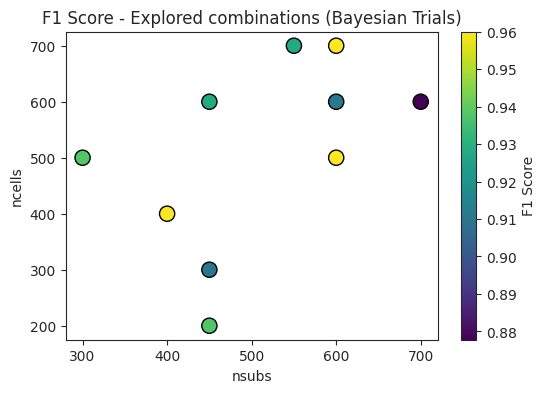

In [28]:

save_lopo_ens_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'
LOPO_folds = len([fold_name for fold_name in list(os.listdir(save_lopo_ens_dir)) if 'fold' in fold_name])
print(LOPO_folds)


save_tuning_plot_dir = f'{cellcnn_path}/experiments/experiment_{plot_exp}/bayesian_tuning/'
os.makedirs(save_tuning_plot_dir, exist_ok=True)

tuning_exp_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/'

heatmap_dict_3d = generate_dict_comb_3d(LOPO_folds, tuning_exp_dir)
sns.set_style('darkgrid')
show_heat_map_combinations(heatmap_dict_3d, save_dir = save_tuning_plot_dir) # heatmap of the tuned parameters combinations
sns.set_style("ticks")


In [29]:
tuned_theta_df = pd.DataFrame(heatmap_dict_3d)
tuned_theta_df

,ncells,nsubs,f1
0,200,450,0.937778
1,700,600,0.960000
2,700,550,0.927778
3,600,450,0.927778
4,500,300,0.937778
5,300,450,0.910000
6,500,600,0.960000
7,600,700,0.877778
8,600,600,0.911111
9,400,400,0.960000


# Thresholds from BO and Ensemble post-training

In [33]:
thrs_dict = {}

BO_roc_thresholds = []
BO_res_thresholds = []
for LOPO_idx, _ in enumerate(range(LOPO_folds)):

    tuning_load_dir = f'{cellcnn_path}/experiments/experiment_{tuning_exp}/outer_fold_{LOPO_idx}/tuning/results'

    threshold_data = load_tuning_data(tuning_load_dir)

    robust_threshold =threshold_data['robust_threshold']
    roc_threshold =threshold_data['roc_threshold']
    BO_roc_thresholds.append(roc_threshold)
    BO_res_thresholds.append(robust_threshold)

thrs_dict['BO_ROC'] = BO_roc_thresholds
thrs_dict['BO_RES'] = BO_res_thresholds

exp = 'Trial_4_NO_AS_Ensemble'
no_as_ens_roc_thr_per_fold, no_as_ens_res_thr_per_fold = retrieve_all_LOPO_ensemble_thresholds(LOPO_folds, cellcnn_path, exp)
thrs_dict['NO_AS_ROC'] = no_as_ens_roc_thr_per_fold
thrs_dict['NO_AS_RES'] = no_as_ens_res_thr_per_fold

exp = 'Trial_4_AS_Ensemble'

as_ens_roc_thr_per_fold, as_ens_res_thr_per_fold = retrieve_all_LOPO_ensemble_thresholds(LOPO_folds, cellcnn_path, exp)
thrs_dict['AS_ROC'] = as_ens_roc_thr_per_fold
thrs_dict['AS_RES'] = as_ens_res_thr_per_fold

thrs_df = pd.DataFrame(thrs_dict)
thrs_df

,BO_ROC,BO_RES,NO_AS_ROC,NO_AS_RES,AS_ROC,AS_RES
0,0.580919,0.50,0.589529,0.78,0.470267,0.46
1,0.649454,0.50,0.635230,0.58,0.468126,0.50
2,0.744908,0.74,0.731488,0.77,0.421762,0.44
3,0.644309,0.65,0.739984,0.74,0.428423,0.41
4,0.681786,0.50,0.732295,0.67,0.445361,0.44
5,0.672843,0.73,0.667170,0.57,0.466269,0.46
6,0.787222,0.77,0.921140,0.91,0.402345,0.39
7,0.636352,0.61,0.682140,0.65,0.411828,0.40
8,0.674158,0.66,0.716857,0.68,0.455933,0.43
9,0.640859,0.50,0.653649,0.50,0.444638,0.44
